In [9]:
import pandas as pd
from pathlib import Path

In [10]:
# Standardized benchmark

if True:
    import re
    import numpy as np
    import pandas as pd
    from pathlib import Path

    # ----------------------------
    # Config
    # ----------------------------
    root_path = Path("/home/kkondo/code/sando_ws/src/sando/benchmark_data")

    folders = {
        "single_thread": [
            "sando_4_benchmark.csv",
            "sando_5_benchmark.csv",
            "sando_6_benchmark.csv",
            "original_faster_4_benchmark.csv",
            "original_faster_5_benchmark.csv",
            "original_faster_6_benchmark.csv",
        ],
        "multi_thread": [
            "sando_4_benchmark.csv",
            "sando_5_benchmark.csv",
            "sando_6_benchmark.csv",
        ],
    }

    SERIES = [
        {
            "label": "original faster (single)",
            "mode": "single_thread",
            "planner": "original_faster",
        },
        {"label": "sando (single)", "mode": "single_thread", "planner": "sando"},
        {"label": "sando (multi)", "mode": "multi_thread", "planner": "sando"},
    ]

    # Required mean columns for sando/faster (over successful runs)
    DYN_REQUIRED_MEAN_COLS = [
        "per_opt_runtime_ms",
        "total_opt_runtime_ms",
        "total_traj_time_sec",
    ]

    # SUPER has no total_opt_runtime_ms (per your note), but has total_traj_time_sec
    SUPER_MEAN_COLS = [
        "per_opt_runtime_ms",
        "total_traj_time_sec",
    ]

    SMOOTHNESS_COLS = ["jerk_smoothness_l1", "jerk_rms"]
    LENGTH_COLS = ["traj_length_m"]

    # Violation-rate columns for sando/faster (booleans)
    DYN_VIOL_BOOL_COLS = {
        "sfc": "corridor_violated",
        "v": "v_violated",
        "a": "a_violated",
        "j": "j_violated",
    }

    # Max-violation magnitude columns for sando/faster (scalars per case)
    DYN_MAX_VIOL_COLS = {
        "sfc": "corridor_max_min_violation",
        "v": "v_max_excess",
        "a": "a_max_excess",
        "j": "j_max_excess",
    }

    # SUPER CSV
    SUPER_CSV_PATH = Path(
        "/media/kkondo/kota_elements/super/super_local_traj_benchmark.csv"
    )
    SUPER_VIOL_VAL_COLS = {
        "sfc": "max_sfc_violation",
        "v": "max_vel_violation",
        "a": "max_acc_violation",
        "j": "max_jerk_violation",
    }
    SUPER_TOL = 1e-3  # violation if > tol

    # ----------------------------
    # Helpers
    # ----------------------------
    def parse_success(x):
        if pd.isna(x):
            return np.nan
        if isinstance(x, (int, float, np.integer, np.floating)):
            return int(x)
        s = str(x).strip().lower()
        if s in {"1", "true", "t", "yes", "y", "ok", "success"}:
            return 1
        if s in {"0", "false", "f", "no", "n", "fail", "failure"}:
            return 0
        try:
            return int(float(s))
        except Exception:
            return np.nan

    pat = re.compile(r"^(?P<planner>.+)_(?P<N>\d+)_benchmark\.csv$")

    def series_mask(df, mode, planner):
        return (df["mode"] == mode) & (df["planner_from_file"] == planner)

    def add_series_label(df):
        df = df.copy()
        df["series_label"] = None
        for s in SERIES:
            mask = series_mask(df, s["mode"], s["planner"])
            df.loc[mask, "series_label"] = s["label"]
        return df

    def safe_mean(series):
        if series is None:
            return np.nan
        s = series.dropna()
        if s.empty:
            return np.nan
        return float(s.mean())

    def as_bool01(series):
        if series is None:
            return None
        if series.dtype == bool:
            return series.astype(float)
        return pd.to_numeric(series, errors="coerce")

    def fmt_cell(x):
        """Print '-' for NaN, else numeric with 6 decimals; keep strings unchanged."""
        if isinstance(x, str):
            return x
        if x is None:
            return "-"
        try:
            if pd.isna(x):
                return "-"
        except Exception:
            pass
        try:
            return f"{float(x):.4f}"
        except Exception:
            return str(x)

    # ----------------------------
    # Load sando/faster CSVs
    # ----------------------------
    dfs = []
    missing = []

    for mode, files in folders.items():
        for f in files:
            m = pat.match(f)
            if not m:
                raise ValueError(
                    f"Filename does not match '<planner>_<N>_benchmark.csv': {f}"
                )

            planner_from_file = m.group("planner")
            N_from_file = int(m.group("N"))

            path = root_path / mode / f
            if not path.exists():
                missing.append(str(path))
                continue

            df = pd.read_csv(path)
            df["mode"] = mode
            df["source_csv"] = f
            df["planner_from_file"] = planner_from_file
            df["N"] = N_from_file
            dfs.append(df)

    if missing:
        print("WARNING: missing sando/faster CSVs were skipped:")
        for p in missing:
            print("  ", p)

    if not dfs:
        raise RuntimeError(
            "No sando/faster CSVs loaded. Check root_path/folder structure and filenames."
        )

    data_all = pd.concat(dfs, ignore_index=True)

    # ----------------------------
    # Clean sando/faster columns
    # ----------------------------
    if "success" not in data_all.columns:
        raise KeyError("Column 'success' not found in sando/faster CSV(s).")
    data_all["success"] = data_all["success"].apply(parse_success)

    # Required sando/faster mean cols
    for c in DYN_REQUIRED_MEAN_COLS:
        if c not in data_all.columns:
            raise KeyError(f"Column '{c}' not found in sando/faster CSV(s).")
        data_all[c] = pd.to_numeric(data_all[c], errors="coerce")

    # Optional metrics
    for c in SMOOTHNESS_COLS + LENGTH_COLS:
        if c in data_all.columns:
            data_all[c] = pd.to_numeric(data_all[c], errors="coerce")

    # Violation rates and max magnitudes
    for c in DYN_VIOL_BOOL_COLS.values():
        if c in data_all.columns:
            data_all[c] = as_bool01(data_all[c])

    for c in DYN_MAX_VIOL_COLS.values():
        if c in data_all.columns:
            data_all[c] = pd.to_numeric(data_all[c], errors="coerce")

    # Add labels and keep only selected series
    data_all = add_series_label(data_all)
    data_all = data_all[data_all["series_label"].notna()].copy()

    # Known attempts for denominators
    known_mask = data_all["success"].isin([0, 1])
    data_known = data_all.loc[known_mask].copy()

    # ----------------------------
    # Build sando/faster summary rows
    # ----------------------------
    rows = []

    have_dyn_viol_rates = all(
        col in data_known.columns for col in DYN_VIOL_BOOL_COLS.values()
    )
    have_dyn_max_viol = all(
        col in data_known.columns for col in DYN_MAX_VIOL_COLS.values()
    )

    for (series_label, N), g in data_known.groupby(["series_label", "N"], sort=True):
        opt_success_rate = safe_mean(g["success"])

        # violation rates among successful optimizations
        sfc_violate_rate = np.nan
        v_violate_rate = np.nan
        a_violate_rate = np.nan
        j_violate_rate = np.nan

        # trajectory success rate: success AND no constraint violations
        traj_success_rate = np.nan
        if have_dyn_viol_rates:
            g_succ = g[g["success"] == 1].copy()

            if not g_succ.empty:
                sfc_violate_rate = safe_mean(g_succ[DYN_VIOL_BOOL_COLS["sfc"]])
                v_violate_rate = safe_mean(g_succ[DYN_VIOL_BOOL_COLS["v"]])
                a_violate_rate = safe_mean(g_succ[DYN_VIOL_BOOL_COLS["a"]])
                j_violate_rate = safe_mean(g_succ[DYN_VIOL_BOOL_COLS["j"]])

            safe_mask = (
                (g["success"] == 1)
                & (g[DYN_VIOL_BOOL_COLS["sfc"]] == 0)
                & (g[DYN_VIOL_BOOL_COLS["v"]] == 0)
                & (g[DYN_VIOL_BOOL_COLS["a"]] == 0)
                & (g[DYN_VIOL_BOOL_COLS["j"]] == 0)
            )
            traj_success_rate = float(safe_mask.mean()) if len(g) > 0 else np.nan

        # means over successful runs
        g_succ = g[g["success"] == 1].copy()

        def mean_over_success(col):
            if col in g_succ.columns and not g_succ.empty:
                return safe_mean(g_succ[col])
            return np.nan

        # mean max violation magnitudes across all cases (NaN-skip)
        mean_max_sfc_violation = np.nan
        mean_max_v_violation = np.nan
        mean_max_a_violation = np.nan
        mean_max_j_violation = np.nan
        if have_dyn_max_viol:
            mean_max_sfc_violation = safe_mean(g[DYN_MAX_VIOL_COLS["sfc"]])
            mean_max_v_violation = safe_mean(g[DYN_MAX_VIOL_COLS["v"]])
            mean_max_a_violation = safe_mean(g[DYN_MAX_VIOL_COLS["a"]])
            mean_max_j_violation = safe_mean(g[DYN_MAX_VIOL_COLS["j"]])

        rows.append(
            {
                "planner_name": series_label,
                "N": int(N),
                "success_rate": opt_success_rate,
                "traj_success_rate": traj_success_rate,
                "per_opt_runtime_ms": mean_over_success("per_opt_runtime_ms"),
                "total_opt_runtime_ms": mean_over_success("total_opt_runtime_ms"),
                "total_traj_time_sec": mean_over_success("total_traj_time_sec"),
                "jerk_smoothness_l1": mean_over_success("jerk_smoothness_l1"),
                "jerk_rms": mean_over_success("jerk_rms"),
                "traj_length_m": mean_over_success("traj_length_m"),
                "sfc_violate_rate": sfc_violate_rate,
                "v_violate_rate": v_violate_rate,
                "a_violate_rate": a_violate_rate,
                "j_violate_rate": j_violate_rate,
                "mean_max_sfc_violation": mean_max_sfc_violation,
                "mean_max_v_violation": mean_max_v_violation,
                "mean_max_a_violation": mean_max_a_violation,
                "mean_max_j_violation": mean_max_j_violation,
            }
        )

    dyn_table = pd.DataFrame(rows)
    fmt_cell
    super_row = None
    if SUPER_CSV_PATH.exists():
        super_df = pd.read_csv(SUPER_CSV_PATH)

        if "success" not in super_df.columns:
            raise KeyError("Column 'success' not found in SUPER CSV.")
        super_df["success"] = super_df["success"].apply(parse_success)

        # Coerce numeric fields that exist in SUPER schema
        for c in (
            SUPER_MEAN_COLS
            + SMOOTHNESS_COLS
            + LENGTH_COLS
            + list(SUPER_VIOL_VAL_COLS.values())
        ):
            if c in super_df.columns:
                super_df[c] = pd.to_numeric(super_df[c], errors="coerce")

        super_known = super_df["success"].isin([0, 1])
        g = super_df.loc[super_known].copy()

        opt_success_rate = safe_mean(g["success"])

        have_super_viol_vals = all(c in g.columns for c in SUPER_VIOL_VAL_COLS.values())

        # trajectory success rate: success and all max_*_violation <= tol
        traj_success_rate = np.nan
        if have_super_viol_vals:
            safe_mask = (
                (g["success"] == 1)
                & (g[SUPER_VIOL_VAL_COLS["sfc"]] <= SUPER_TOL)
                & (g[SUPER_VIOL_VAL_COLS["v"]] <= SUPER_TOL)
                & (g[SUPER_VIOL_VAL_COLS["a"]] <= SUPER_TOL)
                & (g[SUPER_VIOL_VAL_COLS["j"]] <= SUPER_TOL)
            )
            traj_success_rate = float(safe_mask.mean()) if len(g) > 0 else np.nan

        g_succ = g[g["success"] == 1].copy()

        def mean_over_success_super(col):
            if col in g_succ.columns and not g_succ.empty:
                return safe_mean(g_succ[col])
            return np.nan

        # violation rates among successful optimizations
        sfc_violate_rate = np.nan
        v_violate_rate = np.nan
        a_violate_rate = np.nan
        j_violate_rate = np.nan
        if have_super_viol_vals and not g_succ.empty:
            sfc_violate_rate = safe_mean(
                (g_succ[SUPER_VIOL_VAL_COLS["sfc"]] > SUPER_TOL).astype(float)
            )
            v_violate_rate = safe_mean(
                (g_succ[SUPER_VIOL_VAL_COLS["v"]] > SUPER_TOL).astype(float)
            )
            a_violate_rate = safe_mean(
                (g_succ[SUPER_VIOL_VAL_COLS["a"]] > SUPER_TOL).astype(float)
            )
            j_violate_rate = safe_mean(
                (g_succ[SUPER_VIOL_VAL_COLS["j"]] > SUPER_TOL).astype(float)
            )

        # mean max-violation magnitudes across all cases (NaN-skip)
        mean_max_sfc_violation = (
            safe_mean(g[SUPER_VIOL_VAL_COLS["sfc"]]) if have_super_viol_vals else np.nan
        )
        mean_max_v_violation = (
            safe_mean(g[SUPER_VIOL_VAL_COLS["v"]]) if have_super_viol_vals else np.nan
        )
        mean_max_a_violation = (
            safe_mean(g[SUPER_VIOL_VAL_COLS["a"]]) if have_super_viol_vals else np.nan
        )
        mean_max_j_violation = (
            safe_mean(g[SUPER_VIOL_VAL_COLS["j"]]) if have_super_viol_vals else np.nan
        )

        super_row = {
            "planner_name": "super",
            "N": "-",
            "success_rate": opt_success_rate,
            "traj_success_rate": traj_success_rate,
            "per_opt_runtime_ms": mean_over_success_super("per_opt_runtime_ms"),
            # USER REQUEST: SUPER has no total_opt_runtime_ms -> print '-'
            "total_opt_runtime_ms": "-",
            # USER REQUEST: SUPER total_traj_time_sec exists -> compute mean over successful runs
            "total_traj_time_sec": mean_over_success_super("total_traj_time_sec"),
            "jerk_smoothness_l1": mean_over_success_super("jerk_smoothness_l1"),
            "jerk_rms": mean_over_success_super("jerk_rms"),
            "traj_length_m": mean_over_success_super("traj_length_m"),
            "sfc_violate_rate": sfc_violate_rate,
            "v_violate_rate": v_violate_rate,
            "a_violate_rate": a_violate_rate,
            "j_violate_rate": j_violate_rate,
            "mean_max_sfc_violation": mean_max_sfc_violation,
            "mean_max_v_violation": mean_max_v_violation,
            "mean_max_a_violation": mean_max_a_violation,
            "mean_max_j_violation": mean_max_j_violation,
        }
    else:
        print("WARNING: SUPER CSV not found at:", str(SUPER_CSV_PATH))

    # ----------------------------
    # Final table print
    # ----------------------------
    final_cols = [
        "planner_name",
        "N",
        "success_rate",
        "traj_success_rate",
        "per_opt_runtime_ms",
        "total_opt_runtime_ms",
        "total_traj_time_sec",
        "jerk_smoothness_l1",
        "jerk_rms",
        "traj_length_m",
        "sfc_violate_rate",
        "v_violate_rate",
        "a_violate_rate",
        "j_violate_rate",
        "mean_max_sfc_violation",
        "mean_max_v_violation",
        "mean_max_a_violation",
        "mean_max_j_violation",
    ]

    out_tbl = dyn_table.copy()
    if super_row is not None:
        out_tbl = pd.concat([out_tbl, pd.DataFrame([super_row])], ignore_index=True)

    for c in final_cols:
        if c not in out_tbl.columns:
            out_tbl[c] = np.nan

    def sort_key_N(x):
        try:
            return int(x)
        except Exception:
            return 10**9

    out_tbl["_N_sort"] = out_tbl["N"].apply(sort_key_N)
    out_tbl["_is_super"] = (out_tbl["planner_name"] == "super").astype(int)
    out_tbl = out_tbl.sort_values(["_is_super", "_N_sort", "planner_name"]).drop(
        columns=["_N_sort", "_is_super"]
    )

    print("\n=== Unified Benchmark Summary Table (SUPER total_opt_runtime_ms='-') ===")
    print(out_tbl[final_cols].map(fmt_cell).to_string(index=False))

    # Warnings if expected columns are missing
    missing_rate_cols = [
        c for c in DYN_VIOL_BOOL_COLS.values() if c not in data_known.columns
    ]
    if missing_rate_cols:
        print(
            "\nWARNING: sando/faster missing violation-rate columns:", missing_rate_cols
        )

    missing_max_cols = [
        c for c in DYN_MAX_VIOL_COLS.values() if c not in data_known.columns
    ]
    if missing_max_cols:
        print(
            "\nWARNING: sando/faster missing max-violation magnitude columns:",
            missing_max_cols,
        )

   /home/kkondo/code/sando_ws/src/sando/benchmark_data/single_thread/sando_4_benchmark.csv
   /home/kkondo/code/sando_ws/src/sando/benchmark_data/single_thread/sando_5_benchmark.csv
   /home/kkondo/code/sando_ws/src/sando/benchmark_data/single_thread/sando_6_benchmark.csv
   /home/kkondo/code/sando_ws/src/sando/benchmark_data/single_thread/original_faster_4_benchmark.csv
   /home/kkondo/code/sando_ws/src/sando/benchmark_data/single_thread/original_faster_5_benchmark.csv
   /home/kkondo/code/sando_ws/src/sando/benchmark_data/single_thread/original_faster_6_benchmark.csv
   /home/kkondo/code/sando_ws/src/sando/benchmark_data/multi_thread/sando_4_benchmark.csv
   /home/kkondo/code/sando_ws/src/sando/benchmark_data/multi_thread/sando_5_benchmark.csv
   /home/kkondo/code/sando_ws/src/sando/benchmark_data/multi_thread/sando_6_benchmark.csv


RuntimeError: No sando/faster CSVs loaded. Check root_path/folder structure and filenames.

In [ ]:
# For VE benchmarking

if True:
    import re
    import numpy as np
    import pandas as pd
    from pathlib import Path

    # ----------------------------
    # Config (UPDATED for new ve_benchmark folder)
    # ----------------------------
    root_path = Path("/home/kkondo/code/sando_ws/src/sando/benchmark_data")

    # New structure: all files in ve_benchmark/ folder
    # Filenames: sando_N_with_ve_benchmark.csv or sando_N_without_ve_benchmark.csv
    VE_FOLDER = root_path / "ve_benchmark"

    # Pattern to match: <planner>_<N>_<ve_status>_benchmark.csv
    # where ve_status is either "with_ve" or "without_ve"
    pat = re.compile(
        r"^(?P<planner>.+)_(?P<N>\d+)_(?P<ve_status>with_ve|without_ve)_benchmark\.csv$"
    )

    # ----------------------------
    # Existing config from your cell (UNCHANGED)
    # ----------------------------
    DYN_REQUIRED_MEAN_COLS = [
        "per_opt_runtime_ms",
        "total_opt_runtime_ms",
        "total_traj_time_sec",
    ]
    SMOOTHNESS_COLS = ["jerk_smoothness_l1", "jerk_rms"]
    LENGTH_COLS = ["traj_length_m"]

    DYN_VIOL_BOOL_COLS = {
        "sfc": "corridor_violated",
        "v": "v_violated",
        "a": "a_violated",
        "j": "j_violated",
    }
    DYN_MAX_VIOL_COLS = {
        "sfc": "corridor_max_min_violation",
        "v": "v_max_excess",
        "a": "a_max_excess",
        "j": "j_max_excess",
    }

    SUPER_CSV_PATH = Path(
        "/media/kkondo/kota_elements/super/super_local_traj_benchmark.csv"
    )
    SUPER_MEAN_COLS = [
        "per_opt_runtime_ms",
        "total_traj_time_sec",
    ]
    SUPER_VIOL_VAL_COLS = {
        "sfc": "max_sfc_violation",
        "v": "max_vel_violation",
        "a": "max_acc_violation",
        "j": "max_jerk_violation",
    }
    SUPER_TOL = 1e-3

    # ----------------------------
    # Helpers (UNCHANGED)
    # ----------------------------
    def parse_success(x):
        if pd.isna(x):
            return np.nan
        if isinstance(x, (int, float, np.integer, np.floating)):
            return int(x)
        s = str(x).strip().lower()
        if s in {"1", "true", "t", "yes", "y", "ok", "success"}:
            return 1
        if s in {"0", "false", "f", "no", "n", "fail", "failure"}:
            return 0
        try:
            return int(float(s))
        except Exception:
            return np.nan

    def safe_mean(series):
        if series is None:
            return np.nan
        s = series.dropna()
        if s.empty:
            return np.nan
        return float(s.mean())

    def as_bool01(series):
        if series is None:
            return None
        if series.dtype == bool:
            return series.astype(float)
        return pd.to_numeric(series, errors="coerce")

    def fmt_cell(x):
        """Print '-' for NaN, else numeric with 4 decimals; keep strings unchanged."""
        if isinstance(x, str):
            return x
        if x is None:
            return "-"
        try:
            if pd.isna(x):
                return "-"
        except Exception:
            pass
        try:
            return f"{float(x):.4f}"
        except Exception:
            return str(x)

    # ----------------------------
    # Load CSVs from ve_benchmark folder (UPDATED)
    # ----------------------------
    dfs = []
    missing = []

    if not VE_FOLDER.exists():
        print(f"ERROR: VE benchmark folder does not exist: {VE_FOLDER}")
        print("Please run: python3 run_benchmark_suite.py --ve-comparison")
        raise RuntimeError(f"Missing folder: {VE_FOLDER}")

    for file_path in VE_FOLDER.glob("*_benchmark.csv"):
        filename = file_path.name
        m = pat.match(filename)

        if not m:
            print(f"WARNING: Skipping file with unexpected format: {filename}")
            continue

        planner_from_file = m.group("planner")
        N_from_file = int(m.group("N"))
        ve_status = m.group("ve_status")  # "with_ve" or "without_ve"

        # Map to yes/no for consistency with previous code
        ve_flag = "yes" if ve_status == "with_ve" else "no"

        if not file_path.exists():
            missing.append(str(file_path))
            continue

        df = pd.read_csv(file_path)
        df["mode"] = "multi_thread"  # VE comparison uses multi-threaded SANDO
        df["variable_elimination"] = ve_flag
        df["source_csv"] = filename
        df["planner_from_file"] = planner_from_file
        df["N"] = N_from_file

        # Set series label
        if planner_from_file == "sando":
            df["series_label"] = "sando (multi)"
        elif planner_from_file == "faster":
            df["series_label"] = "faster (multi)"
        else:
            df["series_label"] = planner_from_file

        dfs.append(df)

    if missing:
        print("WARNING: missing CSVs were skipped:")
        for p in missing:
            print("  ", p)

    if not dfs:
        print("ERROR: No CSVs loaded from ve_benchmark folder.")
        print(
            "Expected files like: sando_4_with_ve_benchmark.csv, sando_4_without_ve_benchmark.csv"
        )
        print(f"Location: {VE_FOLDER}")
        raise RuntimeError("No CSVs loaded. Check folder structure and filenames.")

    data_all = pd.concat(dfs, ignore_index=True)

    # ----------------------------
    # Clean sando/faster columns (UNCHANGED)
    # ----------------------------
    if "success" not in data_all.columns:
        raise KeyError("Column 'success' not found in CSV(s).")
    data_all["success"] = data_all["success"].apply(parse_success)

    for c in DYN_REQUIRED_MEAN_COLS:
        if c not in data_all.columns:
            raise KeyError(f"Column '{c}' not found in CSV(s).")
        data_all[c] = pd.to_numeric(data_all[c], errors="coerce")

    for c in SMOOTHNESS_COLS + LENGTH_COLS:
        if c in data_all.columns:
            data_all[c] = pd.to_numeric(data_all[c], errors="coerce")

    for c in DYN_VIOL_BOOL_COLS.values():
        if c in data_all.columns:
            data_all[c] = as_bool01(data_all[c])

    for c in DYN_MAX_VIOL_COLS.values():
        if c in data_all.columns:
            data_all[c] = pd.to_numeric(data_all[c], errors="coerce")

    # Known attempts for denominators
    known_mask = data_all["success"].isin([0, 1])
    data_known = data_all.loc[known_mask].copy()

    # ----------------------------
    # Build sando/faster summary rows (group includes variable_elimination)
    # ----------------------------
    rows = []

    have_dyn_viol_rates = all(
        col in data_known.columns for col in DYN_VIOL_BOOL_COLS.values()
    )
    have_dyn_max_viol = all(
        col in data_known.columns for col in DYN_MAX_VIOL_COLS.values()
    )

    group_keys = ["variable_elimination", "series_label", "N"]

    for (ve_flag, series_label, N), g in data_known.groupby(group_keys, sort=True):
        opt_success_rate = safe_mean(g["success"])

        # violation rates among successful optimizations
        sfc_violate_rate = np.nan
        v_violate_rate = np.nan
        a_violate_rate = np.nan
        j_violate_rate = np.nan

        traj_success_rate = np.nan
        if have_dyn_viol_rates:
            g_succ_only = g[g["success"] == 1].copy()
            if not g_succ_only.empty:
                sfc_violate_rate = safe_mean(g_succ_only[DYN_VIOL_BOOL_COLS["sfc"]])
                v_violate_rate = safe_mean(g_succ_only[DYN_VIOL_BOOL_COLS["v"]])
                a_violate_rate = safe_mean(g_succ_only[DYN_VIOL_BOOL_COLS["a"]])
                j_violate_rate = safe_mean(g_succ_only[DYN_VIOL_BOOL_COLS["j"]])

            safe_mask = (
                (g["success"] == 1)
                & (g[DYN_VIOL_BOOL_COLS["sfc"]] == 0)
                & (g[DYN_VIOL_BOOL_COLS["v"]] == 0)
                & (g[DYN_VIOL_BOOL_COLS["a"]] == 0)
                & (g[DYN_VIOL_BOOL_COLS["j"]] == 0)
            )
            traj_success_rate = float(safe_mask.mean()) if len(g) > 0 else np.nan

        g_succ = g[g["success"] == 1].copy()

        def mean_over_success(col):
            if col in g_succ.columns and not g_succ.empty:
                return safe_mean(g_succ[col])
            return np.nan

        mean_max_sfc_violation = np.nan
        mean_max_v_violation = np.nan
        mean_max_a_violation = np.nan
        mean_max_j_violation = np.nan
        if have_dyn_max_viol:
            mean_max_sfc_violation = safe_mean(g[DYN_MAX_VIOL_COLS["sfc"]])
            mean_max_v_violation = safe_mean(g[DYN_MAX_VIOL_COLS["v"]])
            mean_max_a_violation = safe_mean(g[DYN_MAX_VIOL_COLS["a"]])
            mean_max_j_violation = safe_mean(g[DYN_MAX_VIOL_COLS["j"]])

        rows.append(
            {
                "variable_elimination": ve_flag,
                "planner_name": series_label,
                "N": int(N),
                "success_rate": opt_success_rate,
                "traj_success_rate": traj_success_rate,
                "per_opt_runtime_ms": mean_over_success("per_opt_runtime_ms"),
                "total_opt_runtime_ms": mean_over_success("total_opt_runtime_ms"),
                "total_traj_time_sec": mean_over_success("total_traj_time_sec"),
                "jerk_smoothness_l1": mean_over_success("jerk_smoothness_l1"),
                "jerk_rms": mean_over_success("jerk_rms"),
                "traj_length_m": mean_over_success("traj_length_m"),
                "sfc_violate_rate": sfc_violate_rate,
                "v_violate_rate": v_violate_rate,
                "a_violate_rate": a_violate_rate,
                "j_violate_rate": j_violate_rate,
                "mean_max_sfc_violation": mean_max_sfc_violation,
                "mean_max_v_violation": mean_max_v_violation,
                "mean_max_a_violation": mean_max_a_violation,
                "mean_max_j_violation": mean_max_j_violation,
            }
        )

    dyn_table = pd.DataFrame(rows)

    # ----------------------------
    # SUPER row (OPTIONAL: set variable_elimination='-')
    # ----------------------------
    super_row = None
    if SUPER_CSV_PATH.exists():
        super_df = pd.read_csv(SUPER_CSV_PATH)
        if "success" not in super_df.columns:
            raise KeyError("Column 'success' not found in SUPER CSV.")
        super_df["success"] = super_df["success"].apply(parse_success)

        for c in (
            SUPER_MEAN_COLS
            + SMOOTHNESS_COLS
            + LENGTH_COLS
            + list(SUPER_VIOL_VAL_COLS.values())
        ):
            if c in super_df.columns:
                super_df[c] = pd.to_numeric(super_df[c], errors="coerce")

        super_known = super_df["success"].isin([0, 1])
        g = super_df.loc[super_known].copy()

        opt_success_rate = safe_mean(g["success"])
        have_super_viol_vals = all(c in g.columns for c in SUPER_VIOL_VAL_COLS.values())

        traj_success_rate = np.nan
        if have_super_viol_vals:
            safe_mask = (
                (g["success"] == 1)
                & (g[SUPER_VIOL_VAL_COLS["sfc"]] <= SUPER_TOL)
                & (g[SUPER_VIOL_VAL_COLS["v"]] <= SUPER_TOL)
                & (g[SUPER_VIOL_VAL_COLS["a"]] <= SUPER_TOL)
                & (g[SUPER_VIOL_VAL_COLS["j"]] <= SUPER_TOL)
            )
            traj_success_rate = float(safe_mask.mean()) if len(g) > 0 else np.nan

        g_succ = g[g["success"] == 1].copy()

        def mean_over_success_super(col):
            if col in g_succ.columns and not g_succ.empty:
                return safe_mean(g_succ[col])
            return np.nan

        sfc_violate_rate = np.nan
        v_violate_rate = np.nan
        a_violate_rate = np.nan
        j_violate_rate = np.nan
        if have_super_viol_vals and not g_succ.empty:
            sfc_violate_rate = safe_mean(
                (g_succ[SUPER_VIOL_VAL_COLS["sfc"]] > SUPER_TOL).astype(float)
            )
            v_violate_rate = safe_mean(
                (g_succ[SUPER_VIOL_VAL_COLS["v"]] > SUPER_TOL).astype(float)
            )
            a_violate_rate = safe_mean(
                (g_succ[SUPER_VIOL_VAL_COLS["a"]] > SUPER_TOL).astype(float)
            )
            j_violate_rate = safe_mean(
                (g_succ[SUPER_VIOL_VAL_COLS["j"]] > SUPER_TOL).astype(float)
            )

        mean_max_sfc_violation = (
            safe_mean(g[SUPER_VIOL_VAL_COLS["sfc"]]) if have_super_viol_vals else np.nan
        )
        mean_max_v_violation = (
            safe_mean(g[SUPER_VIOL_VAL_COLS["v"]]) if have_super_viol_vals else np.nan
        )
        mean_max_a_violation = (
            safe_mean(g[SUPER_VIOL_VAL_COLS["a"]]) if have_super_viol_vals else np.nan
        )
        mean_max_j_violation = (
            safe_mean(g[SUPER_VIOL_VAL_COLS["j"]]) if have_super_viol_vals else np.nan
        )

        super_row = {
            "variable_elimination": "-",
            "planner_name": "super",
            "N": "-",
            "success_rate": opt_success_rate,
            "traj_success_rate": traj_success_rate,
            "per_opt_runtime_ms": mean_over_success_super("per_opt_runtime_ms"),
            "total_opt_runtime_ms": "-",
            "total_traj_time_sec": mean_over_success_super("total_traj_time_sec"),
            "jerk_smoothness_l1": mean_over_success_super("jerk_smoothness_l1"),
            "jerk_rms": mean_over_success_super("jerk_rms"),
            "traj_length_m": mean_over_success_super("traj_length_m"),
            "sfc_violate_rate": sfc_violate_rate,
            "v_violate_rate": v_violate_rate,
            "a_violate_rate": a_violate_rate,
            "j_violate_rate": j_violate_rate,
            "mean_max_sfc_violation": mean_max_sfc_violation,
            "mean_max_v_violation": mean_max_v_violation,
            "mean_max_a_violation": mean_max_a_violation,
            "mean_max_j_violation": mean_max_j_violation,
        }
    else:
        print("WARNING: SUPER CSV not found at:", str(SUPER_CSV_PATH))

    # ----------------------------
    # Final table print (CHANGED: use ve_out_tbl instead of out_tbl)
    # ----------------------------
    final_cols = [
        "variable_elimination",
        "planner_name",
        "N",
        "success_rate",
        "traj_success_rate",
        "per_opt_runtime_ms",
        "total_opt_runtime_ms",
        "total_traj_time_sec",
        "jerk_smoothness_l1",
        "jerk_rms",
        "traj_length_m",
        "sfc_violate_rate",
        "v_violate_rate",
        "a_violate_rate",
        "j_violate_rate",
        "mean_max_sfc_violation",
        "mean_max_v_violation",
        "mean_max_a_violation",
        "mean_max_j_violation",
    ]

    ve_out_tbl = dyn_table.copy()
    if super_row is not None:
        ve_out_tbl = pd.concat(
            [ve_out_tbl, pd.DataFrame([super_row])], ignore_index=True
        )

    for c in final_cols:
        if c not in ve_out_tbl.columns:
            ve_out_tbl[c] = np.nan

    def sort_key_N(x):
        try:
            return int(x)
        except Exception:
            return 10**9

    # Sort: super last, then variable_elimination (yes first), then N, then planner_name
    ve_out_tbl["_N_sort"] = ve_out_tbl["N"].apply(sort_key_N)
    ve_out_tbl["_is_super"] = (ve_out_tbl["planner_name"] == "super").astype(int)
    ve_out_tbl["_ve_sort"] = (
        ve_out_tbl["variable_elimination"]
        .map({"yes": 0, "no": 1})
        .fillna(9)
        .astype(int)
    )

    ve_out_tbl = ve_out_tbl.sort_values(
        ["_is_super", "_ve_sort", "_N_sort", "planner_name"]
    ).drop(columns=["_N_sort", "_is_super", "_ve_sort"])

    print("\n=== Variable Elimination Comparison Table (multi-threaded SANDO) ===")
    print(ve_out_tbl[final_cols].map(fmt_cell).to_string(index=False))

    # Warnings if expected columns are missing
    missing_rate_cols = [
        c for c in DYN_VIOL_BOOL_COLS.values() if c not in data_known.columns
    ]
    if missing_rate_cols:
        print("\nWARNING: missing violation-rate columns:", missing_rate_cols)

    missing_max_cols = [
        c for c in DYN_MAX_VIOL_COLS.values() if c not in data_known.columns
    ]
    if missing_max_cols:
        print("\nWARNING: missing max-violation magnitude columns:", missing_max_cols)

ERROR: VE benchmark folder does not exist: /home/kkondo/code/dynus_ws/src/sando/benchmark_data/ve_benchmark
Please run: python3 run_benchmark_suite.py --ve-comparison


RuntimeError: Missing folder: /home/kkondo/code/dynus_ws/src/sando/benchmark_data/ve_benchmark

In [ ]:
# Jupyter cell: plot T_opt, T_total, T_trav vs N for SANDO(single), SANDO(multi), FASTER
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

# -------------------- Font Configuration (LaTeX rendering) --------------------
# Configure fonts for publication-quality plots
plt.rcParams.update({"text.usetex": True})
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": 15,
        "axes.titlesize": 16,
        "axes.labelsize": 16,
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,
        "legend.fontsize": 13,
    }
)

# -------------------- Save controls --------------------
SAVE_DIR = "/home/kkondo/paper_writing/SANDO_paper/figures/sim/standardized"
SAVE_NAME = "standardized_times_vs_N.pdf"
SAVE_PATH = os.path.join(SAVE_DIR, SAVE_NAME)

# -------------------- Extract data from out_tbl DataFrame --------------------
# The out_tbl DataFrame is created in the first cell and contains benchmark results

N = np.array([4, 5, 6])

# Define which planners we want to plot
planner_mapping = {
    "SANDO (multi)": "sando (multi)",
    "SANDO (single)": "sando (single)",
    "FASTER": "original faster (single)",  # Using original FASTER only
}

# Debug: Print available planners in out_tbl
print("\n=== DEBUG: Available planners in out_tbl ===")
print(out_tbl["planner_name"].unique())
print("\n=== DEBUG: out_tbl shape ===")
print(out_tbl.shape)
print("\n=== DEBUG: Extracting data for plotting ===")

# Extract data for each planner
data = {}
for display_name, df_name in planner_mapping.items():
    print(f"\nLooking for planner: {df_name}")

    # Filter out_tbl for this planner
    planner_data = out_tbl[out_tbl["planner_name"] == df_name].sort_values("N")
    print(f"  Found {len(planner_data)} rows")

    if len(planner_data) > 0:
        print(f"  N values: {planner_data['N'].values}")

    # Extract values for each N
    T_opt_ms = []
    T_total_ms = []
    T_trav_s = []

    for n in N:
        row = planner_data[planner_data["N"] == n]
        if not row.empty:
            T_opt_ms.append(row["per_opt_runtime_ms"].values[0])
            T_total_ms.append(row["total_opt_runtime_ms"].values[0])
            T_trav_s.append(row["total_traj_time_sec"].values[0])
            print(
                f"  N={n}: T_opt={T_opt_ms[-1]:.2f} ms, T_total={T_total_ms[-1]:.2f} ms, T_trav={T_trav_s[-1]:.2f} s"
            )
        else:
            # If data missing for this N, use NaN
            T_opt_ms.append(np.nan)
            T_total_ms.append(np.nan)
            T_trav_s.append(np.nan)
            print(f"  N={n}: MISSING DATA")

    data[display_name] = {
        "T_opt_ms": np.array(T_opt_ms),
        "T_total_ms": np.array(T_total_ms),
        "T_trav_s": np.array(T_trav_s),
    }

series_order = ["SANDO (multi)", "SANDO (single)", "FASTER"]

print("\n=== DEBUG: Summary of extracted data ===")
for name in series_order:
    print(f"{name}:")
    print(f"  T_opt_ms: {data[name]['T_opt_ms']}")
    print(f"  Has valid data: {not np.all(np.isnan(data[name]['T_opt_ms']))}")

# -------------------- Style controls --------------------
styles = {
    "SANDO (multi)": dict(color="seagreen", marker="s"),
    "SANDO (single)": dict(color="royalblue", marker="o"),
    "FASTER": dict(color="red", marker="^", linestyle=":"),
}

# -------------------- Layout knobs --------------------
HSPACE = 0.32
FIGSIZE = (8.0, 4.5)

LEGEND_FONT = 13
LEGEND_ANCHOR = (1.02, 0.5)
RIGHT_MARGIN = 0.80

# -------------------- Plot --------------------
fig, axes = plt.subplots(
    3, 1, sharex=True, figsize=FIGSIZE, gridspec_kw={"hspace": HSPACE}
)


def plot_panel(ax, key, ylabel, title):
    for name in series_order:
        st = styles[name]
        ax.plot(
            N,
            data[name][key],
            linewidth=2.2,
            linestyle=st.get("linestyle", "-"),
            marker=st["marker"],
            markersize=7.5,
            color=st["color"],
            label=name,
        )
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


plot_panel(
    axes[0],
    key="T_opt_ms",
    ylabel=r"$T^{\mathrm{per}}_{\mathrm{opt}}$ [ms]",
    title=r"Per-optimization Computation Time: $T^{\mathrm{per}}_{\mathrm{opt}}$",
)

plot_panel(
    axes[1],
    key="T_total_ms",
    ylabel=r"$T^{\mathrm{total}}_{\mathrm{opt}}$ [ms]",
    title=r"Total Optimization Computation Time: $T^{\mathrm{total}}_{\mathrm{opt}}$",
)

plot_panel(
    axes[2],
    key="T_trav_s",
    ylabel=r"$T_{\mathrm{trav}}$ [s]",
    title=r"Trajectory Travel Time: $T_{\mathrm{trav}}$",
)

axes[2].set_xlabel(r"$N$")
axes[2].set_xticks(N)

# --- Right-side legend centered vertically for the whole stack ---
handles, labels = axes[0].get_legend_handles_labels()

# Remove any per-axes legends
for ax in axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

# Reserve right space for legend
RIGHT_MARGIN = 0.80
fig.tight_layout(rect=[0.0, 0.0, RIGHT_MARGIN, 1.0])

# Figure-level legend, centered vertically (middle-right)
fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(RIGHT_MARGIN - 0.1, 0.25),
    frameon=False,
    fontsize=LEGEND_FONT,
    ncol=1,
    handlelength=2.2,
    labelspacing=0.6,
    borderaxespad=0.0,
)

# -------------------- Save to PDF --------------------
os.makedirs(SAVE_DIR, exist_ok=True)
fig.savefig(SAVE_PATH, format="pdf", bbox_inches="tight", pad_inches=0.0)
print(f"\n[OK] Saved: {SAVE_PATH}")

plt.show()


=== DEBUG: Available planners in out_tbl ===


NameError: name 'out_tbl' is not defined

[OK] Saved: /home/kkondo/paper_writing/SANDO_paper/figures/sim/standardized/combined_standardized.png


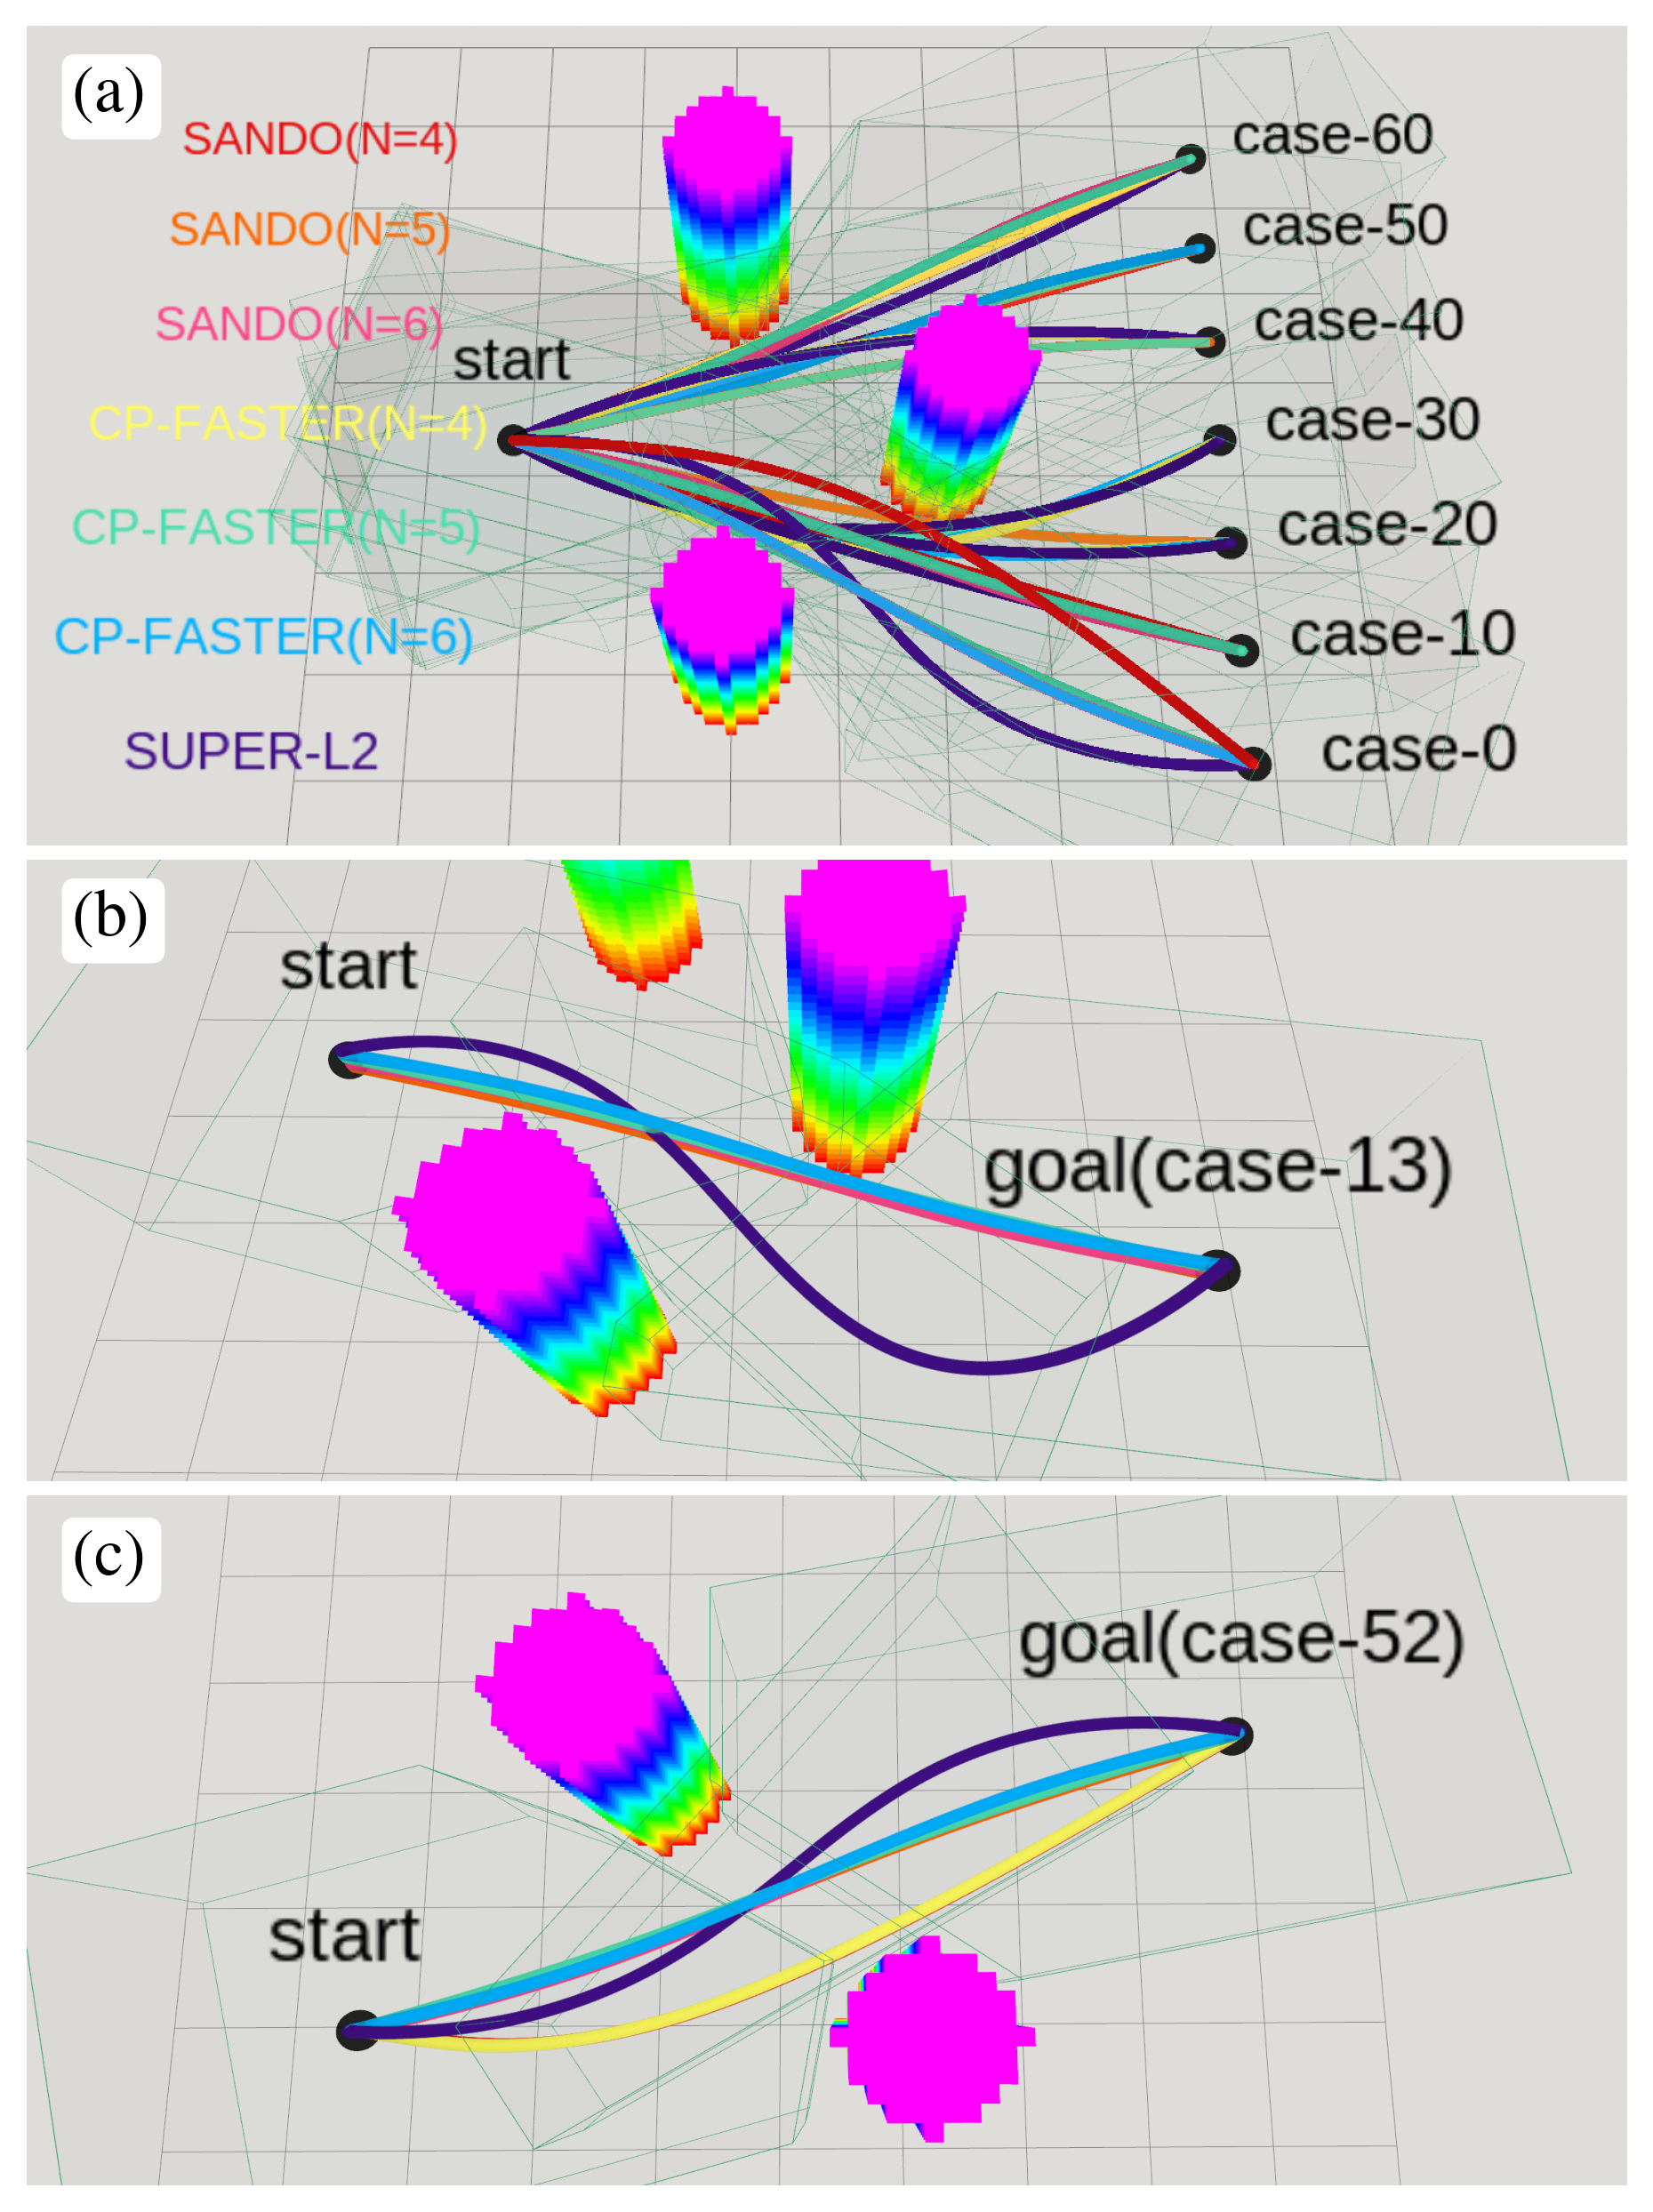

In [14]:
"""
Vertical stack layout (3 images):

[ img0 ]
[ img1 ]
[ img2 ]

- Cropping is supported per image using PER_RIGHT_IMAGE_CROP (reused from your script).
- Font settings are unchanged from your pasted code.
- Adds a planner legend (colored line + label) on the LEFT side of the first image,
  directly below the (a) label.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.lines import Line2D

# ================== User parameters (edit these) ==================

# Input / output
INPUT_DIR = "/home/kkondo/paper_writing/SANDO_paper/figures/sim/standardized"
FILENAMES = [
    "standardized_all.png",
    "standardized_case13.png",
    "standardized_case52.png",
]
OUTPUT_DIR = INPUT_DIR
OUTPUT_NAME = "combined_standardized.png"

# Figure
FIG_DPI = 300
FIG_W_IN = 6.0
FIG_H_IN = 7.0

# Spacing
HSPACE = 0.02

# Row size ratios for the 3 stacked images (top/mid/bot)
ROW_RATIOS = [1.6, 1.4, 1.4]

# --------- Cropping (pixels) ---------
# Order corresponds to FILENAMES (img0, img1, img2).
PER_RIGHT_IMAGE_CROP = [
    {"top": 300, "bottom": 350, "left": 1000, "right": 900},  # img0
    {"top": 300, "bottom": 200, "left": 550, "right": 500},  # img1
    {"top": 200, "bottom": 200, "left": 500, "right": 550},  # img2
]

# Labels (you can keep 4; code will safely use only first 3)
LABELS = ["(a)", "(b)", "(c)", "(d)"]
LABEL_SIZE = 18
LABEL_COLOR = "black"
LABEL_FAMILY = "Times New Roman"
LABEL_OFFSET_AXES = (0.03, 0.05)

# Label badge style
LABEL_BADGE = True
BADGE_FACE = "white"
BADGE_EDGE = "white"
BADGE_ALPHA = 1.0
BADGE_LINEWIDTH = 1.5
BADGE_PAD = 0.15
BADGE_ROUNDING = 0.15

# Fonts / TeX
USE_TEX = False
TNR_TTF_PATH = None

# Placeholder if an image is missing (so script still runs)
PLACEHOLDER_H = 540
PLACEHOLDER_W = 960
PLACEHOLDER_GRAY = 0.90

# ------------------ Legend settings (NEW) ------------------

LEGEND_ITEMS = [
    ("#e51010", "SANDO (N=4)"),  # red
    ("#ff6600", "SANDO (N=5)"),  # orange
    ("#fc4589", "SANDO (N=6)"),  # pink
    ("#fffc5d", "FASTER (N=4)"),  # yellow
    ("#4adeaf", "FASTER (N=5)"),  # mint
    ("#00b2ff", "FASTER (N=6)"),  # cyan
    ("#420e87", "SUPER"),  # purple
]

# Legend anchor in AXES coordinates of the first panel (ax0)
# Put it below (a): same x as label, and a bit lower y.
LEGEND_ANCHOR_AXES = (0.025, 0.82)  # (x, y) in axes fraction
LEGEND_FONT_SIZE = 16
LEGEND_LINEWIDTH = 3.5
LEGEND_HANDLELEN = 1.2
LEGEND_LABELSPACING = 0.35
LEGEND_FRAME = True
LEGEND_FRAME_ALPHA = 1.0

# ================== End user parameters ==================


def _apply_fonts():
    # UNCHANGED from your pasted code
    plt.rcParams.update({"text.usetex": USE_TEX})
    if TNR_TTF_PATH is not None and os.path.exists(TNR_TTF_PATH):
        font_manager.fontManager.addfont(TNR_TTF_PATH)
    font = font_manager.FontProperties()
    font.set_family("serif")
    font.set_size(LABEL_SIZE)
    plt.rcParams.update({"text.usetex": True})
    plt.rcParams["font.family"] = LABEL_FAMILY


def _read_image(path: str) -> np.ndarray:
    img = plt.imread(path)
    if img is None:
        raise FileNotFoundError(f"Could not read: {path}")
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    if img.shape[-1] == 4:
        img = img[..., :3]
    return img


def _crop_image(
    img: np.ndarray, top: int, bottom: int, left: int, right: int
) -> np.ndarray:
    h, w = img.shape[0], img.shape[1]
    top = int(max(0, min(top, h - 1)))
    bottom = int(max(0, min(bottom, h - 1)))
    left = int(max(0, min(left, w - 1)))
    right = int(max(0, min(right, w - 1)))

    if top + bottom >= h:
        top = h // 4
        bottom = h // 4
    if left + right >= w:
        left = w // 4
        right = w // 4

    return img[top : h - bottom, left : w - right, :]


def _get_crop_from_dict(d: dict, fallback: dict):
    return (
        d.get("top", fallback.get("top", 0)),
        d.get("bottom", fallback.get("bottom", 0)),
        d.get("left", fallback.get("left", 0)),
        d.get("right", fallback.get("right", 0)),
    )


def _get_image_crop(i: int):
    fallback = {"top": 0, "bottom": 0, "left": 0, "right": 0}

    if PER_RIGHT_IMAGE_CROP is None:
        d = fallback
    else:
        if len(PER_RIGHT_IMAGE_CROP) < len(FILENAMES):
            raise ValueError(
                "PER_RIGHT_IMAGE_CROP must have at least len(FILENAMES) entries (or be None)."
            )
        d = PER_RIGHT_IMAGE_CROP[i]
        if d is None:
            d = fallback

    return _get_crop_from_dict(d, fallback)


def _load_images_with_crop():
    images = []
    for i, name in enumerate(FILENAMES):
        path = os.path.join(INPUT_DIR, name)

        if not os.path.exists(path):
            ph = np.full(
                (PLACEHOLDER_H, PLACEHOLDER_W, 3), PLACEHOLDER_GRAY, dtype=float
            )
            images.append(ph)
            print(f"[WARN] Missing file, using placeholder: {path}")
            continue

        img = _read_image(path)
        t, b, l, r = _get_image_crop(i)
        img = _crop_image(img, t, b, l, r)
        images.append(img)

    return images


def _add_label(ax, text: str):
    x = LABEL_OFFSET_AXES[0]
    y = 1.0 - LABEL_OFFSET_AXES[1]

    bbox = None
    if LABEL_BADGE:
        bbox = dict(
            boxstyle=f"round,pad={BADGE_PAD},rounding_size={BADGE_ROUNDING}",
            facecolor=BADGE_FACE,
            edgecolor=BADGE_EDGE,
            linewidth=BADGE_LINEWIDTH,
            alpha=BADGE_ALPHA,
        )

    ax.text(
        x,
        y,
        text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=LABEL_SIZE,
        color=LABEL_COLOR,
        family=LABEL_FAMILY,
        bbox=bbox,
        zorder=6,
    )


def _add_planner_legend(ax):
    # Create small colored line handles + labels
    handles = [
        Line2D([0], [0], color=hex_color, lw=LEGEND_LINEWIDTH)
        for (hex_color, _) in LEGEND_ITEMS
    ]
    labels = [name for (_, name) in LEGEND_ITEMS]

    leg = ax.legend(
        handles,
        labels,
        loc="upper left",
        bbox_to_anchor=LEGEND_ANCHOR_AXES,  # in axes coords
        borderaxespad=0.0,
        frameon=LEGEND_FRAME,
        fontsize=LEGEND_FONT_SIZE,
        handlelength=LEGEND_HANDLELEN,
        labelspacing=LEGEND_LABELSPACING,
        ncol=1,
    )

    if LEGEND_FRAME:
        leg.get_frame().set_alpha(LEGEND_FRAME_ALPHA)
        leg.get_frame().set_facecolor("white")
        leg.get_frame().set_edgecolor("white")

    # Ensure legend text uses your existing family (do not change global font settings)
    for txt in leg.get_texts():
        txt.set_family(LABEL_FAMILY)


# ================== Run (Jupyter cell) ==================
_apply_fonts()

if len(FILENAMES) != 3:
    raise ValueError(
        "This vertical-stack script expects exactly 3 images in FILENAMES."
    )

imgs = _load_images_with_crop()

# Use only the first 3 labels; if you provided fewer, auto-generate missing ones.
labels3 = (
    LABELS[:3]
    if len(LABELS) >= 3
    else LABELS + [f"({chr(ord('a') + i)})" for i in range(len(LABELS), 3)]
)

# Compute height ratios from actual cropped image dimensions to preserve aspect ratio.
# Each image is displayed at FIG_W_IN width, so its natural height = FIG_W_IN * (H/W).
ROW_RATIOS = [img.shape[0] / img.shape[1] for img in imgs]
FIG_H_IN = FIG_W_IN * sum(ROW_RATIOS)

fig = plt.figure(figsize=(FIG_W_IN, FIG_H_IN), dpi=FIG_DPI, facecolor="white")

gs = gridspec.GridSpec(
    3,
    1,
    figure=fig,
    height_ratios=ROW_RATIOS,
    hspace=HSPACE,
)

axes = [fig.add_subplot(gs[i, 0]) for i in range(3)]

for ax, img, lab in zip(axes, imgs, labels3):
    ax.imshow(img, aspect="auto")  # IMPORTANT: fill axes -> reduces white band
    ax.axis("off")
    _add_label(ax, lab)

# Add legend on the first image (below (a), left side)
# _add_planner_legend(axes[0])

os.makedirs(OUTPUT_DIR, exist_ok=True)
save_path = os.path.join(OUTPUT_DIR, OUTPUT_NAME)

fig.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=1.0, hspace=HSPACE)
fig.savefig(save_path, bbox_inches="tight", pad_inches=0.0, facecolor="white")
print(f"[OK] Saved: {save_path}")

plt.show()